<div style="background: linear-gradient(135deg, #0f2027 0%, #203a43 50%, #2c5364 100%); padding: 40px 36px; border-radius: 16px; color: white; font-family: 'Segoe UI', sans-serif; border-left: 6px solid #00b4d8;">
  <div style="font-size: 12px; color: #90e0ef; letter-spacing: 3px; text-transform: uppercase; font-weight: 600;">
    SCY1101 — Evaluación Parcial 2 · Notebook 1 de 6
  </div>
  <h1 style="margin: 14px 0 8px; font-size: 32px; font-weight: 700; letter-spacing: -0.5px;">
    🔍 EDA Exploratorio: Logística y Transporte
  </h1>
  <p style="color: #caf0f8; margin: 0 0 24px; font-size: 16px; line-height: 1.6;">
    Antes de construir cualquier modelo, hay que entender los datos.<br>
    Este notebook audita cuatro fuentes operativas y decide qué es confiable para machine learning.
  </p>
  <div style="display: flex; gap: 12px; flex-wrap: wrap;">
    <span style="background: rgba(0,180,216,0.2); color: #90e0ef; padding: 6px 14px; border-radius: 20px; font-size: 13px; border: 1px solid rgba(0,180,216,0.3);">📦 4 fuentes de datos</span>
    <span style="background: rgba(0,180,216,0.2); color: #90e0ef; padding: 6px 14px; border-radius: 20px; font-size: 13px; border: 1px solid rgba(0,180,216,0.3);">🔬 Auditoría de calidad</span>
    <span style="background: rgba(0,180,216,0.2); color: #90e0ef; padding: 6px 14px; border-radius: 20px; font-size: 13px; border: 1px solid rgba(0,180,216,0.3);">🛡️ Anti-leakage</span>
    <span style="background: rgba(0,180,216,0.2); color: #90e0ef; padding: 6px 14px; border-radius: 20px; font-size: 13px; border: 1px solid rgba(0,180,216,0.3);">⚙️ Kedro Pipeline</span>
  </div>
  <div style="margin-top: 24px; background: rgba(255,255,255,0.07); border-radius: 10px; padding: 12px 18px; font-size: 13px; color: #90e0ef;">
    <strong>Barra de progreso del proyecto:</strong>
    <div style="background: rgba(255,255,255,0.15); border-radius: 10px; height: 6px; margin: 8px 0 4px;">
      <div style="background: linear-gradient(90deg, #00b4d8, #48cae4); width: 17%; height: 6px; border-radius: 10px;"></div>
    </div>
    <div style="display: flex; justify-content: space-between; font-size: 11px; color: #caf0f8; opacity: 0.7;">
      <span>▶ EDA</span><span>Modelos</span><span>Evaluación</span><span>Tuning</span><span>Clustering</span><span>Final</span>
    </div>
  </div>
</div>

---

## 🧭 La historia que vamos a contar

<div style="background: #f0f9ff; border-left: 5px solid #0ea5e9; padding: 20px 24px; border-radius: 0 12px 12px 0; margin: 16px 0; font-family: 'Segoe UI', sans-serif;">
  <strong style="color: #0c4a6e; font-size: 15px;">📋 Situación real</strong><br><br>
  <span style="color: #1e3a5f; font-size: 14px; line-height: 1.7;">
    Una empresa de transporte logístico registra sus envíos, rutas, vehículos e incidencias en cuatro bases de datos separadas.
    El problema no es que les falten datos — el problema es que <strong>esos datos tienen errores reales</strong>:
    nulos críticos, rangos anómalos e inconsistencias entre tablas.<br><br>
    Antes de predecir si un envío tendrá una incidencia o cuántos días tardará en llegar,
    hay que responder una pregunta más básica: <strong>¿podemos confiar en los datos?</strong>
  </span>
</div>

**Este notebook recorre el camino desde el dato crudo hasta la decisión de construir un dataset ML confiable:**

1. **Inventariar** las cuatro fuentes y ver qué tan grandes son
2. **Detectar nulos** que podrían engañar a los modelos
3. **Auditar con Kedro** el dataset maestro `master_envios`
4. **Entender las incidencias** — la variable que queremos predecir
5. **Certificar el dataset ML** que alimentará los modelos

> **Regla central del proyecto:** No se entrena sobre datos mal preparados. Primero se audita, luego se modela.

In [2]:
from pathlib import Path
import json
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_RAW = PROJECT_ROOT / "data" / "01_raw"
DATA_MODEL = PROJECT_ROOT / "data" / "05_model_input"
DATA_OUTPUT = PROJECT_ROOT / "data" / "07_model_output"
DATA_REPORT = PROJECT_ROOT / "data" / "08_reporting"
DATA_MODELS = PROJECT_ROOT / "data" / "06_models"

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)


def read_csv(path):
    for enc in ("utf-8", "latin-1"):
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path)


def clean_text_columns(df):
    df = df.copy()
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].astype(str).str.replace("Ã³", "o", regex=False)
    return df


ModuleNotFoundError: No module named 'matplotlib'

---

## 1. 📂 Inventario de datos

<div style="background: #fefce8; border-left: 5px solid #eab308; padding: 14px 20px; border-radius: 0 10px 10px 0; margin: 12px 0;">
  <strong>¿Qué vamos a cargar?</strong><br>
  <span style="font-size: 13px; color: #713f12;">
    Las cuatro tablas operativas crudas (<code>envios</code>, <code>rutas</code>, <code>vehiculos</code>, <code>incidencias</code>)
    más los reportes de validación Kedro y los datasets ML ya procesados.
    El inventario nos dice de entrada si hay desequilibrio entre tablas — por ejemplo,
    si hay muchas más rutas que envíos, o si las incidencias son escasas respecto al total de envíos.
  </span>
</div>

In [2]:
envios = read_csv(DATA_RAW / "envios.csv")
rutas = read_csv(DATA_RAW / "rutas.csv")
vehiculos = read_csv(DATA_RAW / "vehiculos.csv")
incidencias = read_csv(DATA_RAW / "incidencias.csv")

validation_report = read_csv(DATA_REPORT / "validation_report.csv")
model_input_report = read_csv(DATA_REPORT / "model_input_report.csv")
clf = read_csv(DATA_MODEL / "model_input_clasificacion.csv")
reg = read_csv(DATA_MODEL / "model_input_regresion.csv")

inventario = pd.DataFrame({
    "dataset": ["envios", "rutas", "vehiculos", "incidencias", "model_input_clasificacion", "model_input_regresion"],
    "filas": [len(envios), len(rutas), len(vehiculos), len(incidencias), len(clf), len(reg)],
    "columnas": [envios.shape[1], rutas.shape[1], vehiculos.shape[1], incidencias.shape[1], clf.shape[1], reg.shape[1]],
})
inventario


,dataset,filas,columnas
0,envios,1030,9
1,rutas,82,7
2,vehiculos,61,8
3,incidencias,206,6
4,model_input_clasificacion,866,26
5,model_input_regresion,790,26


<div style="background: #f0fdf4; border-left: 5px solid #22c55e; padding: 16px 20px; border-radius: 0 10px 10px 0; margin: 8px 0; font-family: 'Segoe UI', sans-serif;">
  <strong style="color: #166534;">✅ ¿Qué nos dice el inventario?</strong><br><br>
  <span style="color: #14532d; font-size: 14px; line-height: 1.7;">
    Las cuatro tablas crudas son evidencia operativa directa: cada fila en <code>envios</code> es un despacho real,
    cada fila en <code>incidencias</code> es un problema que ocurrió en ruta.<br><br>
    Los datasets <code>model_input_clasificacion</code> (<strong>866 filas</strong>) y <code>model_input_regresion</code> (<strong>790 filas</strong>)
    son versiones filtradas — éstas son las que alimentarán a los modelos.
    La diferencia de 76 filas entre ambos refleja los <strong>74 registros excluidos</strong> por rangos no aptos para ML.
    El pipeline Kedro se encargó de esto automáticamente.
  </span>
</div>

---

## 2. 🔴 Perfil de nulos en datos crudos

<div style="background: #fff1f2; border-left: 5px solid #ef4444; padding: 14px 20px; border-radius: 0 10px 10px 0; margin: 12px 0;">
  <strong>¿Por qué los nulos importan en logística?</strong><br>
  <span style="font-size: 13px; color: #7f1d1d;">
    Un nulo en <code>id_vehiculo</code> no es solo una celda vacía: significa que no sabes qué camión transportó ese envío.
    Un nulo en <code>peso_kg</code> significa que cualquier modelo de eficiencia operativa va a calcular sobre aire.
    En ML, un nulo que se imputa mal contamina el aprendizaje del modelo completo.
    Este gráfico cuantifica exactamente cuántos registros están afectados por variable.
  </span>
</div>

,columna,nulos,dataset,porcentaje
18,tipo,5,vehiculos,8.20
19,capacidad_kg,5,vehiculos,8.20
23,km_recorridos,5,vehiculos,8.20
28,descripcion,16,incidencias,7.77
11,destino,6,rutas,7.32
14,tipo_via,6,rutas,7.32
17,placa,4,vehiculos,6.56
24,id_incidencia,13,incidencias,6.31
13,tiempo_estimado_hrs,5,rutas,6.10
1,fecha_envio,60,envios,5.83


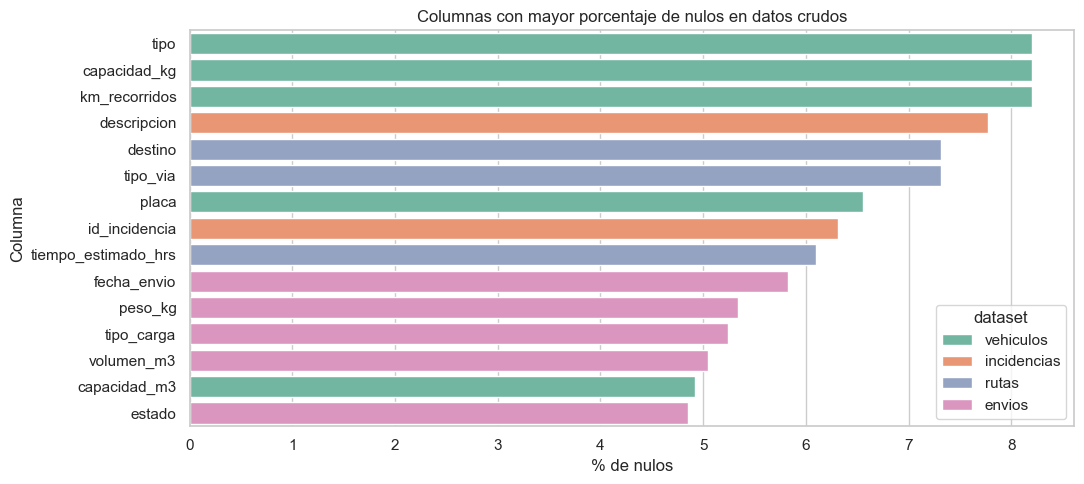

In [3]:
nulos = []
for nombre, df in [("envios", envios), ("rutas", rutas), ("vehiculos", vehiculos), ("incidencias", incidencias)]:
    tmp = df.isna().sum().reset_index()
    tmp.columns = ["columna", "nulos"]
    tmp["dataset"] = nombre
    tmp["porcentaje"] = (tmp["nulos"] / len(df) * 100).round(2)
    nulos.append(tmp)
nulos = pd.concat(nulos, ignore_index=True)

top_nulos = nulos[nulos["nulos"] > 0].sort_values("porcentaje", ascending=False)
display(top_nulos.head(20))

plt.figure(figsize=(11, 5))
sns.barplot(data=top_nulos.head(15), y="columna", x="porcentaje", hue="dataset")
plt.title("Columnas con mayor porcentaje de nulos en datos crudos")
plt.xlabel("% de nulos")
plt.ylabel("Columna")
plt.tight_layout()
plt.show()


<div style="background: #f0f9ff; border: 1px solid #bae6fd; border-radius: 10px; padding: 16px 20px; margin: 8px 0; font-family: 'Segoe UI', sans-serif;">
  <strong style="color: #0c4a6e;">📊 Cómo leer el gráfico de nulos</strong><br><br>
  <span style="color: #1e3a5f; font-size: 14px; line-height: 1.7;">
    Cada barra es una columna con información faltante — mientras más larga, más registros incompletos.<br><br>
    <strong>Lo que esto significa operativamente:</strong><br>
    • <code>id_vehiculo</code> vacío → no se puede rastrear qué unidad operó ese envío<br>
    • <code>costo_impacto</code> vacío → no se puede calcular el impacto financiero real de una incidencia<br>
    • <code>fecha_entrega</code> vacía → la variable objetivo de regresión (<code>dias_en_transito</code>) no se puede construir<br><br>
    <strong>Acción tomada:</strong> ninguno de estos nulos llega al dataset ML. Se imputan por grupo o se excluyen según el tipo de variable.
  </span>
</div>

---

## 3. 🔎 Auditoría Kedro del dataset maestro

<div style="background: #fefce8; border-left: 5px solid #f59e0b; padding: 14px 20px; border-radius: 0 10px 10px 0; margin: 12px 0;">
  <strong>¿Qué es <code>master_envios</code> y por qué tiene errores?</strong><br>
  <span style="font-size: 13px; color: #78350f;">
    <code>master_envios</code> es el dataset consolidado que Kedro construye al unir las cuatro fuentes operativas.
    El pipeline de validación ejecuta checks automáticos y reporta cuántos pasan y cuántos fallan.<br><br>
    Un error en <code>master_envios</code> <strong>no rompe el proyecto</strong> — es evidencia documentada de los
    problemas reales del dataset, como rutas con IDs que no existen en la tabla de rutas o
    vehículos referenciados que no están registrados en el catálogo.
  </span>
</div>

C:\Users\Tg20taps\AppData\Local\Temp\ipykernel_2440\3107930605.py:37: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


,estado,cantidad
0,ERROR,12
1,ADVERTENCIA,6
2,OK,5


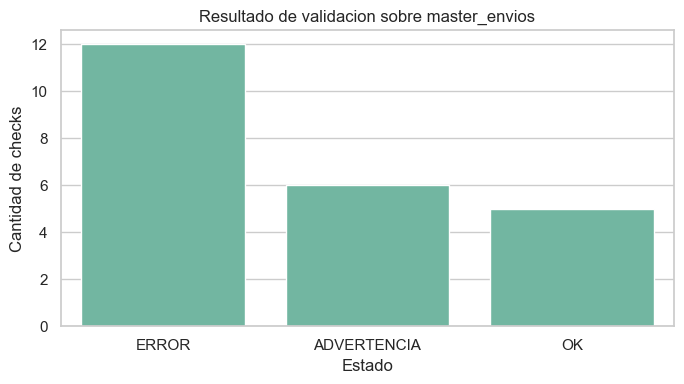

,check,estado,detalle,n_afectados,porcentaje,categoria
12,esquema:id_envio,ADVERTENCIA,dtype actual: float64 | esperado: Int64,0,0.00,esquema
16,esquema:id_vehiculo,ADVERTENCIA,dtype actual: float64 | esperado: Int64,0,0.00,esquema
17,esquema:tiene_incidencia,ADVERTENCIA,dtype actual: int64 | esperado: int8,0,0.00,esquema
13,pandera:id_ruta,ADVERTENCIA,1 registros inválidos en columna 'id_ruta'.,1,0.10,pandera
14,pandera:schema_global,ADVERTENCIA,"93 violaciones en columnas: ['id_envio', 'id_r...",93,9.43,pandera
15,pandera:id_envio,ADVERTENCIA,92 registros inválidos en columna 'id_envio'.,92,9.33,pandera
4,integridad:id_ruta,ERROR,28/986 envíos con id_ruta no encontrado en tab...,28,100.00,integridad
5,integridad:id_vehiculo,ERROR,77/986 envíos con id_vehiculo no encontrado en...,77,100.00,integridad
6,nulos:fecha_envio,ERROR,54/986 nulos (5.48%) en columna crítica.,54,5.48,nulos
7,nulos:id_envio,ERROR,46/986 nulos (4.67%) en columna crítica.,46,4.67,nulos


In [4]:
validation_report = clean_text_columns(validation_report)
resumen_validacion = validation_report["estado"].value_counts().rename_axis("estado").reset_index(name="cantidad")
display(resumen_validacion)

plt.figure(figsize=(7, 4))
sns.barplot(data=resumen_validacion, x="estado", y="cantidad")
plt.title("Resultado de validacion sobre master_envios")
plt.xlabel("Estado")
plt.ylabel("Cantidad de checks")
plt.tight_layout()
plt.show()

display(validation_report.sort_values(["estado", "categoria"]).head(20))


<div style="background: #fff7ed; border: 1px solid #fed7aa; border-radius: 10px; padding: 16px 20px; margin: 8px 0; font-family: 'Segoe UI', sans-serif;">
  <strong style="color: #9a3412;">🔐 Decisión metodológica clave — por qué esto importa para la defensa</strong><br><br>
  <span style="color: #7c2d12; font-size: 14px; line-height: 1.7;">
    El dataset maestro conserva <strong>12 errores de validación</strong>: rutas y vehículos con IDs
    que no cruzan correctamente entre tablas. Esto es una limitación real de integridad referencial.<br><br>
    <strong>¿Qué se decidió?</strong> Mantener <code>master_envios</code> tal cual como evidencia de calidad real,
    y crear datasets de modelado <em>filtrados y certificados</em> en <code>data/05_model_input/</code>.<br><br>
    Esta es la diferencia entre hacer ML bien y hacerlo rápido: los modelos <strong>nunca ven</strong>
    los 12 registros problemáticos. La evidencia queda documentada pero aislada.
  </span>
</div>

---

## 4. ⚠️ Incidencias: la variable que queremos predecir

<div style="background: #fdf4ff; border-left: 5px solid #a855f7; padding: 14px 20px; border-radius: 0 10px 10px 0; margin: 12px 0;">
  <strong>¿Por qué las incidencias son el corazón del problema?</strong><br>
  <span style="font-size: 13px; color: #581c87;">
    Una incidencia logística puede ser un retraso, un daño en carga, una falla mecánica o una desviación de ruta.
    Cada incidencia tiene un costo operativo y de imagen. Si el modelo puede anticipar qué envíos tienen alta
    probabilidad de incidencia, la empresa puede intervenir antes de que ocurra el problema —
    reasignar vehículos, reforzar rutas críticas o alertar al equipo de operaciones.
  </span>
</div>

,tipo_incidencia,cantidad
0,Accidente,44
1,Retraso,38
2,Desvío de ruta,36
3,Daño en carga,32
4,Robo,25
5,Falla mecánica,25


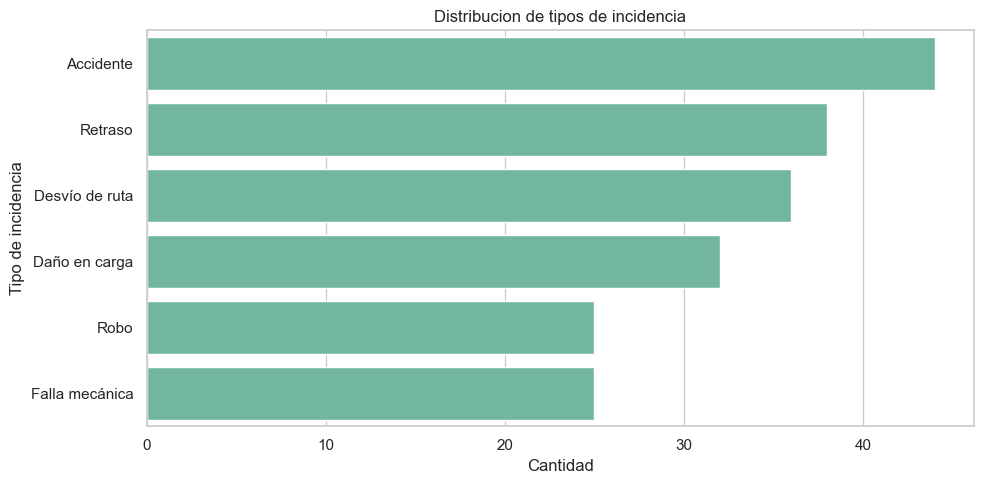

,tiene_incidencia,cantidad,clase,porcentaje
0,0,720,Sin incidencia,83.14
1,1,146,Con incidencia,16.86


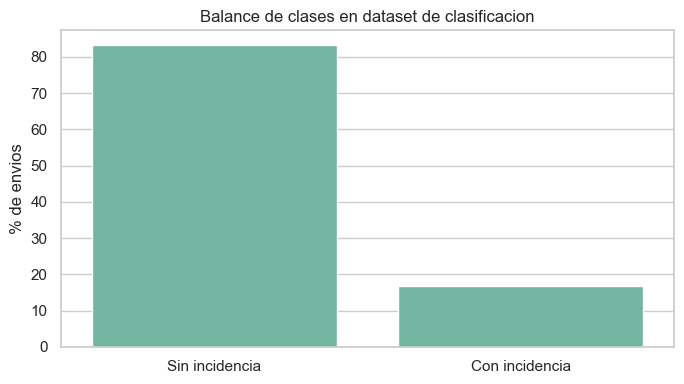

In [5]:
if "tipo_incidencia" in incidencias.columns:
    inc_tipo = incidencias["tipo_incidencia"].value_counts().reset_index()
    inc_tipo.columns = ["tipo_incidencia", "cantidad"]
    display(inc_tipo)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=inc_tipo, y="tipo_incidencia", x="cantidad")
    plt.title("Distribucion de tipos de incidencia")
    plt.xlabel("Cantidad")
    plt.ylabel("Tipo de incidencia")
    plt.tight_layout()
    plt.show()

balance = clf["tiene_incidencia"].value_counts().sort_index().reset_index()
balance.columns = ["tiene_incidencia", "cantidad"]
balance["clase"] = balance["tiene_incidencia"].map({0: "Sin incidencia", 1: "Con incidencia"})
balance["porcentaje"] = (balance["cantidad"] / balance["cantidad"].sum() * 100).round(2)
display(balance)

plt.figure(figsize=(7, 4))
sns.barplot(data=balance, x="clase", y="porcentaje")
plt.title("Balance de clases en dataset de clasificacion")
plt.xlabel("")
plt.ylabel("% de envios")
plt.tight_layout()
plt.show()


<div style="background: #fdf4ff; border: 1px solid #e9d5ff; border-radius: 10px; padding: 16px 20px; margin: 8px 0; font-family: 'Segoe UI', sans-serif;">
  <strong style="color: #581c87;">⚖️ El problema del desbalance de clases — por qué accuracy no sirve aquí</strong><br><br>
  <span style="color: #4a1272; font-size: 14px; line-height: 1.7;">
    La clase positiva (envíos con incidencia) es <strong>minoritaria</strong>.
    Esto tiene una consecuencia directa: si un modelo predice siempre "sin incidencia",
    puede alcanzar un accuracy del 80%+ sin detectar ningún problema real.<br><br>
    <strong>Ejemplo concreto:</strong> si hay 700 envíos sin incidencia y 166 con incidencia,
    un modelo tonto que diga "no hay incidencia" en todos los casos tiene 81% de accuracy —
    pero un 0% de recall. Es inútil para el negocio.<br><br>
    <strong>Por eso en el modelado NO se usa accuracy como métrica principal.</strong>
    Se usa <strong>f1</strong> (que penaliza tanto falsos positivos como falsos negativos)
    y se monitorea especialmente el <strong>recall</strong>: ¿cuántas incidencias reales detecta el modelo?
  </span>
</div>

---

## 5. 📐 Variables operativas: peso, distancia y tiempo

<div style="background: #f0fdf4; border-left: 5px solid #16a34a; padding: 14px 20px; border-radius: 0 10px 10px 0; margin: 12px 0;">
  <strong>¿Qué variables predicen el riesgo logístico?</strong><br>
  <span style="font-size: 13px; color: #14532d;">
    El peso del envío, la distancia de la ruta, el tiempo estimado y la eficiencia de carga
    son las variables operativas más directas. Sus distribuciones revelan si los datos tienen
    rangos anómalos que podrían sesgar el aprendizaje.<br><br>
    Rangos auditados y validados:
    <code>peso_kg</code>: 13.6 — 18,466 kg &nbsp;|&nbsp;
    <code>distancia_km</code>: 29.6 — 1,903 km &nbsp;|&nbsp;
    <code>eficiencia_peso</code>: 0.004 — 9.94
  </span>
</div>

,count,mean,std,min,25%,50%,75%,max
peso_kg,866.0,7083.293880,3993.111667,13.60000,3763.075000,7468.850000,9738.600000,18466.0000
distancia_km,866.0,954.793418,535.481993,29.60000,507.200000,883.700000,1490.800000,1903.4000
tiempo_estimado_hrs,866.0,12.186259,6.601614,0.90000,6.700000,12.200000,18.400000,23.7000
eficiencia_peso,866.0,1.504270,1.678055,0.00421,0.604693,1.105755,1.484895,9.9362


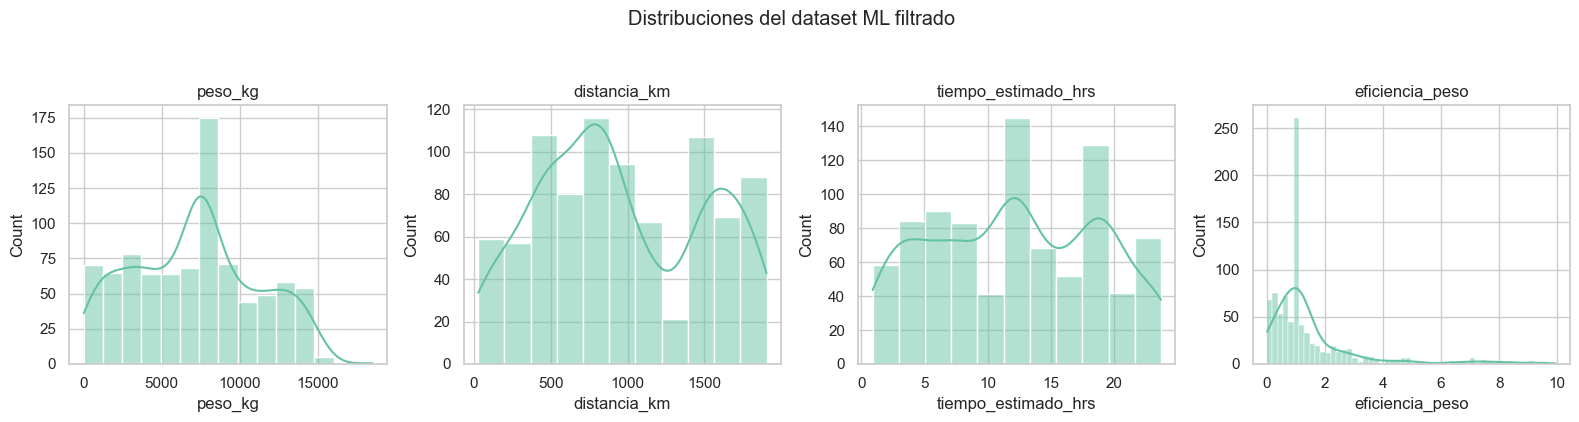

In [6]:
cols_num = [c for c in ["peso_kg", "distancia_km", "tiempo_estimado_hrs", "eficiencia_peso"] if c in clf.columns]
display(clf[cols_num].describe().T)

fig, axes = plt.subplots(1, len(cols_num), figsize=(4 * len(cols_num), 4))
if len(cols_num) == 1:
    axes = [axes]
for ax, col in zip(axes, cols_num):
    sns.histplot(data=clf, x=col, kde=True, ax=ax)
    ax.set_title(col)
plt.suptitle("Distribuciones del dataset ML filtrado", y=1.05)
plt.tight_layout()
plt.show()


<div style="background: #f0fdf4; border: 1px solid #bbf7d0; border-radius: 10px; padding: 16px 20px; margin: 8px 0; font-family: 'Segoe UI', sans-serif;">
  <strong style="color: #166534;">📏 ¿Por qué se eliminaron 74 filas?</strong><br><br>
  <span style="color: #14532d; font-size: 14px; line-height: 1.7;">
    Las distribuciones que se ven aquí son las del <strong>dataset ML filtrado</strong>.
    74 registros fueron excluidos porque tenían valores fuera de rangos operativos razonables
    en <code>peso_kg</code>, <code>distancia_km</code> o <code>eficiencia_peso</code>.<br><br>
    Estos outliers no eran datos útiles para el aprendizaje — eran errores de registro o
    casos extremos que distorsionarían los parámetros de los modelos.
    Excluirlos no es perder información; es proteger la calidad del entrenamiento.
  </span>
</div>

---

## 6. ✅ Auditoría final del dataset ML

<div style="background: #f0f9ff; border-left: 5px solid #0284c7; padding: 14px 20px; border-radius: 0 10px 10px 0; margin: 12px 0;">
  <strong>Tres condiciones obligatorias antes de modelar</strong><br>
  <span style="font-size: 13px; color: #0c4a6e;">
    <strong>① Cero nulos</strong> — un nulo no imputado hace que el modelo aprenda sobre ausencia de información, no sobre patrones reales.<br>
    <strong>② Cero leakage</strong> — variables que revelan el futuro (como <code>fecha_entrega</code> para predecir <code>dias_en_transito</code>) inflan las métricas artificialmente.<br>
    <strong>③ Cero rangos inválidos</strong> — ya auditados y filtrados en el paso anterior.
  </span>
</div>

In [1]:
auditoria = []
for nombre, df in [("clasificacion", clf), ("regresion", reg)]:
    leakage = [
        "total_incidencias", "costo_impacto_total", "tipos_incidencia",
        "costo_impacto_total_norm", "fecha_entrega"
    ]
    auditoria.append({
        "dataset": nombre,
        "filas": len(df),
        "columnas": df.shape[1],
        "nulos_totales": int(df.isna().sum().sum()),
        "columnas_leakage_presentes": ", ".join([c for c in leakage if c in df.columns]) or "ninguna",
    })
pd.DataFrame(auditoria)


NameError: name 'clf' is not defined

In [8]:
display(model_input_report)


,seccion,item,valor,detalle
0,general,filas_master_original,986,Filas en master_envios antes de preparación ML
1,general,filas_eliminadas_id_nulo,46,Filas con id_envio nulo ? registros no identif...
2,general,filas_excluidas_rangos_modelado,74,Filas excluidas del dataset ML por distancia_k...
3,general,columnas_master_original,60,Columnas en master_envios antes de preparación
4,leakage_eliminado,total_incidencias,EXCLUIDA,Data leakage: 'total_incidencias' contiene inf...
5,leakage_eliminado,costo_impacto_total,EXCLUIDA,Data leakage: 'costo_impacto_total' contiene i...
6,leakage_eliminado,tipos_incidencia,EXCLUIDA,Data leakage: 'tipos_incidencia' contiene info...
7,leakage_eliminado,costo_impacto_total_norm,EXCLUIDA,Data leakage: 'costo_impacto_total_norm' conti...
8,post_evento_clasificacion,fecha_entrega,EXCLUIDA,Post-evento: disponible solo DESPUES del envio...
9,post_evento_clasificacion,dias_en_transito,EXCLUIDA,Post-evento: calculado de fecha_entrega - fech...


---

## 🏁 Conclusión: los datos están listos para el modelado

<div style="background: linear-gradient(135deg, #0f2027 0%, #203a43 50%, #2c5364 100%); padding: 28px 32px; border-radius: 12px; color: white; font-family: 'Segoe UI', sans-serif; margin: 16px 0;">
  <h3 style="margin: 0 0 16px; color: #90e0ef;">📋 Resumen ejecutivo del EDA</h3>
  <div style="display: flex; gap: 16px; flex-wrap: wrap; margin-bottom: 20px;">
    <div style="background: rgba(255,255,255,0.1); border-radius: 10px; padding: 16px 20px; flex: 1; min-width: 130px; text-align: center;">
      <div style="font-size: 28px; font-weight: bold; color: #4ade80;">0</div>
      <div style="font-size: 12px; color: #caf0f8; margin-top: 4px;">Nulos en dataset ML</div>
    </div>
    <div style="background: rgba(255,255,255,0.1); border-radius: 10px; padding: 16px 20px; flex: 1; min-width: 130px; text-align: center;">
      <div style="font-size: 28px; font-weight: bold; color: #4ade80;">0</div>
      <div style="font-size: 12px; color: #caf0f8; margin-top: 4px;">Columnas con leakage</div>
    </div>
    <div style="background: rgba(255,255,255,0.1); border-radius: 10px; padding: 16px 20px; flex: 1; min-width: 130px; text-align: center;">
      <div style="font-size: 28px; font-weight: bold; color: #fbbf24;">74</div>
      <div style="font-size: 12px; color: #caf0f8; margin-top: 4px;">Filas excluidas (rango)</div>
    </div>
    <div style="background: rgba(255,255,255,0.1); border-radius: 10px; padding: 16px 20px; flex: 1; min-width: 130px; text-align: center;">
      <div style="font-size: 28px; font-weight: bold; color: #f87171;">12</div>
      <div style="font-size: 12px; color: #caf0f8; margin-top: 4px;">Errores en maestro (documentados)</div>
    </div>
    <div style="background: rgba(255,255,255,0.1); border-radius: 10px; padding: 16px 20px; flex: 1; min-width: 130px; text-align: center;">
      <div style="font-size: 28px; font-weight: bold; color: #60a5fa;">866</div>
      <div style="font-size: 12px; color: #caf0f8; margin-top: 4px;">Envíos certificados para clasificación</div>
    </div>
    <div style="background: rgba(255,255,255,0.1); border-radius: 10px; padding: 16px 20px; flex: 1; min-width: 130px; text-align: center;">
      <div style="font-size: 28px; font-weight: bold; color: #60a5fa;">790</div>
      <div style="font-size: 12px; color: #caf0f8; margin-top: 4px;">Envíos certificados para regresión</div>
    </div>
  </div>
  <p style="color: #caf0f8; margin: 0; font-size: 14px; line-height: 1.7;">
    La EDA no solo confirmó los problemas — los cuantificó y resolvió antes de modelar.
    El dataset maestro conserva sus errores reales como evidencia de calidad real;
    los modelos se entrenan sobre un subconjunto certificado. Eso es ML honesto y defendible.
  </p>
</div>

<div style="background: #eff6ff; border: 1px solid #bfdbfe; border-radius: 10px; padding: 16px 20px; margin-top: 16px; font-family: 'Segoe UI', sans-serif;">
  <strong style="color: #1e40af;">➡️ Siguiente: Notebook 02 — Modelado Supervisado</strong><br>
  <span style="color: #1e3a8a; font-size: 14px;">
    Con los 866 y 790 envíos certificados, se comparan <strong>15 algoritmos candidatos</strong>
    de clasificación y 15 de regresión — con validación cruzada — para responder:
    ¿cuál modelo detecta mejor las incidencias y cuál estima mejor los días de tránsito?
  </span>
</div>